# Definición de Variables para el Modelo de Recomendación

Este notebook define y justifica las variables explicativas (independientes) y la variable objetivo
(dependiente) para un modelo de recomendación de películas. El objetivo es **recomendar las top 5
películas a un usuario cualquiera**.

Se describen los atributos disponibles en el conjunto de datos, se justifica por qué podrían
entrar en un modelo de predicción, y se crean atributos derivados a partir de las variables
originales cuando es necesario.

## 1. Importación de librerías y datos

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

In [16]:
data = pd.read_csv("../../data/processed/data.csv", parse_dates=["datetime"])
user = pd.read_csv("../../data/processed/user.csv", dtype={"zip_code": str})
item = pd.read_csv("../../data/processed/item.csv")

print(f"data: {data.shape[0]} filas, {data.shape[1]} columnas")
print(f"user: {user.shape[0]} filas, {user.shape[1]} columnas")
print(f"item: {item.shape[0]} filas, {item.shape[1]} columnas")

data: 99455 filas, 5 columnas
user: 943 filas, 5 columnas
item: 1661 filas, 22 columnas


## 2. Variable Objetivo: Top 5 Películas por Usuario

### 2.1 Definición

La **variable objetivo** es la lista de las **5 películas con mayor calificación** para cada usuario.
En un problema de recomendación, esto se traduce en predecir qué películas tendrán una calificación
alta (4 o 5 estrellas) para un usuario que aún no las ha calificado.

### 2.2 Justificación

El objetivo del sistema es recomendar películas que al usuario le gustarán. Las calificaciones
altas (4-5 estrellas) son una señal directa de que una película fue bien recibida. Por lo tanto,
predecir si un usuario calificará una película con 4 o 5 estrellas es equivalente a recomendar
películas que le gustarán.

### 2.3 Operacionalización

Para cada usuario, identificamos las películas que calificó con 4 o 5 estrellas como "positivas"
y las que calificó con 1-3 estrellas como "negativas". El modelo buscará predecir la probabilidad
de que un usuario califique positivamente una película que aún no ha visto.

In [17]:
data["positiva"] = data["rating"].isin([4, 5]).astype(int)

print("Distribución de calificaciones positivas (4-5 estrellas):")
print(data["positiva"].value_counts(normalize=True).round(4))
print(f"\nPorcentaje de calificaciones positivas: {data['positiva'].mean()*100:.2f}%")

Distribución de calificaciones positivas (4-5 estrellas):
positiva
1    0.5534
0    0.4466
Name: proportion, dtype: float64

Porcentaje de calificaciones positivas: 55.34%


In [18]:
top5_por_usuario = (
    data[data["positiva"] == 1]
    .groupby("user_id")
    .apply(lambda x: x.nlargest(5, "rating")["item_id"].tolist(), include_groups=False)
    .reset_index(name="top5_items")
)

print(f"Usuarios con al menos 1 calificación positiva: {len(top5_por_usuario)}")
print(f"\nEjemplo (usuario 1):\n{top5_por_usuario.head()}")

Usuarios con al menos 1 calificación positiva: 942

Ejemplo (usuario 1):
   user_id                 top5_items
0        1          [1, 6, 9, 12, 13]
1        2   [50, 100, 127, 242, 251]
2        3  [320, 321, 328, 340, 346]
3        4   [50, 258, 294, 300, 301]
4        5    [42, 89, 100, 101, 109]


## 3. Variables Explicativas (Atributos Característicos)

Las variables explicativas se dividen en tres categorías:

1. **Variables demográficas del usuario** (originales)
2. **Variables de comportamiento del usuario** (derivadas)
3. **Variables de la película** (originales y derivadas)

### 3.1 Variables Demográficas del Usuario

Estas variables provienen directamente de la tabla `user` y describen características
estáticas del usuario.

#### 3.1.1 Edad (`age`)

**Descripción:** Edad del usuario en años.

**Justificación:** La edad es un predictor clásico en sistemas de recomendación. Los estudios
de exploración (`data_user.ipynb`) mostraron correlaciones débiles pero significativas entre
edad y patrones de calificación (ρ = 0.091 para calificación media, ρ = -0.117 para
número de calificaciones). Usuarios jóvenes tienden a preferir Action/Sci-Fi/Horror,
mientras que los mayores prefieren Drama/War/Film-Noir (`data_item_user.ipynb`).

**Tipo:** Numérica continua.

**Transformación recomendada:** Podría agruparse en rangos etarios para capturar
relaciones no lineales.

#### 3.1.2 Género (`gender`)

**Descripción:** Género del usuario (M = masculino, F = femenino).

**Justificación:** Los análisis previos (`data_user.ipynb`, `data_item_user.ipynb`) mostraron
que el género no se asocia con el nivel de calificación (p = 0.993), pero sí con la cantidad
de calificaciones (p = 0.0024) y con preferencias de género: las mujeres califican más
Romance (23.9% vs 19.4%) y los hombres más Action/Sci-Fi. Aunque el tamaño del efecto es
pequeño (|Δ Cliff| < 0.33), es una variable fácil de obtener y complementaria.

**Tipo:** Categórica nominal.

**Transformación recomendada:** One-hot encoding (una columna binaria).

#### 3.1.3 Ocupación (`occupation`)

**Descripción:** Ocupación del usuario (21 categorías: student, engineer, etc.).

**Justificación:** La ocupación refleja el estilo de vida, tiempo disponible y nivel
socioeconómico, todos factores que pueden influir en los gustos cinematográficos.
Un estudiante podría preferir comedias de college, mientras que un ejecutivo podría
preferir dramas corporativos. Aunque no se exploró en detalle en los notebooks
anteriores, es una variable con potencial predictivo.

**Tipo:** Categórica nominal.

**Transformación recomendada:** One-hot encoding o target encoding.

### 3.2 Variables de Comportamiento del Usuario (Derivadas)

Estas variables no existen en los datos originales pero se crean a partir del
cruce de las tablas. Capturan el historial de actividad del usuario.

#### 3.2.1 Número de Calificaciones (`n_calificaciones`)

**Descripción:** Cantidad total de películas calificadas por el usuario.

**Justificación:** Los análisis mostraron que la actividad varía enormemente (de 19 a 734
calificaciones, mediana 64). Los usuarios más activos tienden a ser más críticos y tener
gustos más definidos. Un usuario con 700 calificaciones probablemente tiene preferencias
más claras que uno con 20. Además, el 10% más activo aporta el 32% de todas las
calificaciones, lo que indica que esta variable es clave para entender la fiabilidad
de las preferencias del usuario.

**Tipo:** Numérica discreta.

**Transformación recomendada:** Logaritmo para reducir la asimetría (skewness = 1.90).

#### 3.2.2 Calificación Promedio del Usuario (`calificacion_media`)

**Descripción:** Promedio de todas las calificaciones emitidas por el usuario.

**Justificación:** Algunos usuarios son estrictos (promedio bajo) y otros son
generosos (promedio alto). Conocer la tendencia global del usuario permite
calibrar la predicción: si un usuario promedia 2.5, una película con 3.5 podría
ser buena para él, mientras que si promedia 4.2, necesita una película con 4.5+.
El análisis mostró que la media global es 3.59 con un rango de 1.5 a 4.87.

**Tipo:** Numérica continua.

**Transformación recomendada:** Estandarización (z-score).

#### 3.2.3 Perfil de Género del Usuario (`perfil_genero`)

**Descripción:** Proporción de calificaciones del usuario que corresponden a cada
género cinematográfico (19 columnas, una por género).

**Justificación:** Esta es quizás la variable más importante. Los análisis en
`data_item_user.ipynb` demostraron que los usuarios tienen preferencias de género
claramente diferenciadas y que estas se asocian con el género y la edad del usuario.
Un usuario que calificó el 40% de sus películas como Drama y el 25% como Romance
tiene un perfil muy distinto a uno que calificó el 30% como Action y el 20% como
Sci-Fi. Este perfil captura los gustos del usuario de forma directa.

**Tipo:** Vector de 19 valores numéricos entre 0 y 1.

**Nota:** Esta variable se crea calculando, para cada usuario, la proporción de
sus calificaciones que cae en cada género.

#### 3.2.4 Diversidad de Género (`diversidad_genero`)

**Descripción:** Índice de Shannon o entropía normalizada del perfil de género
del usuario. Mide cuán distribuidas están las calificaciones del usuario entre
los diferentes géneros.

**Justificación:** Un usuario que califica solo Drama tiene baja diversidad, mientras
que uno que califica todos los géneros equitativamente tiene alta diversidad. Los
usuarios con alta diversidad son más difíciles de recomendar pero también más
flexibles. Esta variable resume la información del perfil de género en un solo
número.

**Tipo:** Numérica continua entre 0 y 1.

**Transformación recomendada:** Ninguna (ya está acotada).

#### 3.2.5 Género Preferido (`genero_preferido`)

**Descripción:** Género con mayor proporción en el perfil del usuario.

**Justificación:** Es una simplificación del perfil de género que identifica el
gusto principal del usuario. Útil como filtro categórico en modelos híbridos.

**Tipo:** Categórica nominal (19 niveles).

### 3.3 Variables de la Película

Estas variables describen características de las películas y son constantes
para todos los usuarios.

#### 3.3.1 Géneros de la Película (`Action`, `Adventure`, ..., `Western`)

**Descripción:** 19 columnas binarias que indican a qué género(s) pertenece
cada película. Una película puede pertenecer a múltiples géneros.

**Justificación:** Los géneros son la característica más directa de una película.
Un usuario que prefiere Drama tendrá mayor probabilidad de calificar positivamente
una película de Drama. La exploración en `data_item_user.ipynb` confirmó que
existe una asociación real entre el género de la película y quién la califica.

**Tipo:** 19 columnas binarias (0/1).

**Nota:** Los géneros no son excluyentes: una película puede ser Action + Thriller
+ Crime simultáneamente.

#### 3.3.2 Popularidad de la Película (`popularidad_pelicula`)

**Descripción:** Número total de calificaciones que ha recibido la película.

**Justificación:** Las películas populares tienen más información disponible y
sus calificaciones son más confiables. Una película con 500 calificaciones y
promedio 4.2 es más confiable que una con 3 calificaciones y promedio 4.5.
Además, la popularidad puede indicar un "efecto mainstream" que el modelo
podría capturar.

**Tipo:** Numérica discreta.

**Transformación recomendada:** Logaritmo (la distribución es tipo cola larga).

#### 3.3.3 Calificación Promedio de la Película (`calificacion_media_pelicula`)

**Descripción:** Promedio de todas las calificaciones recibidas por la película.

**Justificación:** Una película con promedio 4.3 es objetivamente mejor recibida
que una con promedio 2.8. Esta variable captura la calidad percibida por la
comunidad. Los análisis mostraron que la media global es 3.08 con un rango de
1 a 5, y que la distribución está sesgada hacia valores positivos.

**Tipo:** Numérica continua.

**Transformación recomendada:** Ninguna (ya está en escala 1-5).

#### 3.3.4 Año de Estreno (`anio_estreno`)

**Descripción:** Año de estreno de la película (derivado de `release_date`).

**Justificación:** La antigüedad de una película puede influir en la
probabilidad de que sea calificada. Las películas más recientes suelen
tener más calificaciones, y los usuarios más jóvenes tienden a preferir
películas más recientes.

**Tipo:** Numérica discreta.

**Nota:** Se extrae de la columna `release_date` que tiene formato
"YYYY-MM-DD".

## 4. Construcción de Variables Derivadas

En esta sección se crean efectivamente las variables derivadas descritas
anteriormente.

In [19]:
data_user = data.merge(user, on="user_id", how="inner")
data_item_user = data_user.merge(
    item[["item_id", "release_date"] + [c for c in item.columns if c not in ["item_id", "title", "release_date", "unknown"]]],
    on="item_id",
    how="inner"
)

print(f"Merge data+user+item: {data_item_user.shape[0]} filas, {data_item_user.shape[1]} columnas")

Merge data+user+item: 99455 filas, 29 columnas


In [20]:
GENEROS = ["Action", "Adventure", "Animation", "Children's", "Comedy", "Crime",
           "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror", "Musical",
           "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western"]

# === Variables derivadas del USUARIO ===
perfil_usuario = data.groupby("user_id").agg(
    n_calificaciones=("rating", "size"),
    calificacion_media=("rating", "mean")
).reset_index()

perfil_usuario = perfil_usuario.merge(user, on="user_id", how="inner")

# Perfil de género: proporción de calificaciones por género para cada usuario
perfil_genero = data_item_user.groupby("user_id")[GENEROS].mean().reset_index()
perfil_usuario = perfil_usuario.merge(perfil_genero, on="user_id", how="inner")

# Diversidad de género (entropía normalizada)
def entropia_normalizada(fila):
    probs = np.array(fila[GENEROS].values, dtype=np.float64)
    probs = probs[probs > 0]
    if len(probs) == 0:
        return 0.0
    H = -np.sum(probs * np.log2(probs))
    H_max = np.log2(len(GENEROS))
    return H / H_max if H_max > 0 else 0.0

perfil_usuario["diversidad_genero"] = perfil_usuario.apply(entropia_normalizada, axis=1)

# Género preferido
perfil_usuario["genero_preferido"] = perfil_usuario[GENEROS].idxmax(axis=1)

print(f"Perfil de usuario: {perfil_usuario.shape[0]} filas")
perfil_usuario[["user_id", "age", "gender", "occupation", "n_calificaciones",
                "calificacion_media", "diversidad_genero", "genero_preferido"]].head()

Perfil de usuario: 943 filas


,user_id,age,gender,occupation,n_calificaciones,calificacion_media,diversidad_genero,genero_preferido
0,1,24,M,technician,270,3.603704,1.267029,Drama
1,2,53,F,other,60,3.750000,1.107333,Drama
2,3,23,M,writer,53,2.773585,1.218115,Drama
3,4,24,M,technician,24,4.333333,1.212253,Thriller
4,5,33,F,other,174,2.867816,1.266576,Comedy


In [21]:
# === Variables derivadas de la PELÍCULA ===
perfil_pelicula = data.groupby("item_id").agg(
    popularidad_pelicula=("rating", "size"),
    calificacion_media_pelicula=("rating", "mean")
).reset_index()

# Año de estreno
item_con_anio = item.copy()
item_con_anio["anio_estreno"] = pd.to_datetime(
    item_con_anio["release_date"], errors="coerce"
).dt.year

perfil_pelicula = perfil_pelicula.merge(
    item_con_anio[["item_id", "anio_estreno"] + GENEROS],
    on="item_id", how="inner"
)

print(f"Perfil de película: {perfil_pelicula.shape[0]} filas")
perfil_pelicula[["item_id", "popularidad_pelicula", "calificacion_media_pelicula",
                 "anio_estreno"]].head()

Perfil de película: 1661 filas


,item_id,popularidad_pelicula,calificacion_media_pelicula,anio_estreno
0,1,452,3.878319,1995
1,2,131,3.206107,1995
2,3,90,3.033333,1995
3,4,209,3.550239,1995
4,5,86,3.302326,1995


## 5. Resumen de Variables y Matriz de Características

### 5.1 Tabla Resumen

In [22]:
resumen_variables = pd.DataFrame({
    "variable": [
        "age", "gender", "occupation",
        "n_calificaciones", "calificacion_media",
        "perfil_genero (19 cols)", "diversidad_genero", "genero_preferido",
        "Action...Western (19 cols)", "popularidad_pelicula",
        "calificacion_media_pelicula", "anio_estreno"
    ],
    "tipo": [
        "Numérica continua", "Categórica (M/F)", "Categórica (21 niveles)",
        "Numérica discreta", "Numérica continua",
        "Vector 19D (0-1)", "Numérica continua (0-1)", "Categórica (19 niveles)",
        "19 binarias (0/1)", "Numérica discreta",
        "Numérica continua", "Numérica discreta"
    ],
    "origen": [
        "user.csv", "user.csv", "user.csv",
        "Derivada (data.csv)", "Derivada (data.csv)",
        "Derivada (data+item)", "Derivada (perfil_genero)", "Derivada (perfil_genero)",
        "item.csv", "Derivada (data.csv)",
        "Derivada (data.csv)", "Derivada (item.csv)"
    ],
    "justificacion": [
        "Asociación con preferencias de género", "Diferencias en cantidad y tipo de calificaciones",
        "Refleja estilo de vida y gustos",
        "Indica claridad de preferencias", "Calibra la predicción según generosidad del usuario",
        "Captura gustos directamente", "Resume la diversidad en un solo número",
        "Identifica el gusto principal",
        "Característica directa de la película", "Indica confiabilidad de la calificación",
        "Captura calidad percibida", "Antigüedad puede influir en preferencia"
    ]
})

print("Tabla resumen de variables:")
resumen_variables

Tabla resumen de variables:


,variable,tipo,origen,justificacion
0,age,Numérica continua,user.csv,Asociación con preferencias de género
1,gender,Categórica (M/F),user.csv,Diferencias en cantidad y tipo de calificaciones
2,occupation,Categórica (21 niveles),user.csv,Refleja estilo de vida y gustos
3,n_calificaciones,Numérica discreta,Derivada (data.csv),Indica claridad de preferencias
4,calificacion_media,Numérica continua,Derivada (data.csv),Calibra la predicción según generosidad del us...
5,perfil_genero (19 cols),Vector 19D (0-1),Derivada (data+item),Captura gustos directamente
6,diversidad_genero,Numérica continua (0-1),Derivada (perfil_genero),Resume la diversidad en un solo número
7,genero_preferido,Categórica (19 niveles),Derivada (perfil_genero),Identifica el gusto principal
8,Action...Western (19 cols),19 binarias (0/1),item.csv,Característica directa de la película
9,popularidad_pelicula,Numérica discreta,Derivada (data.csv),Indica confiabilidad de la calificación


### 5.2 Distribución de las Variables Derivadas Clave

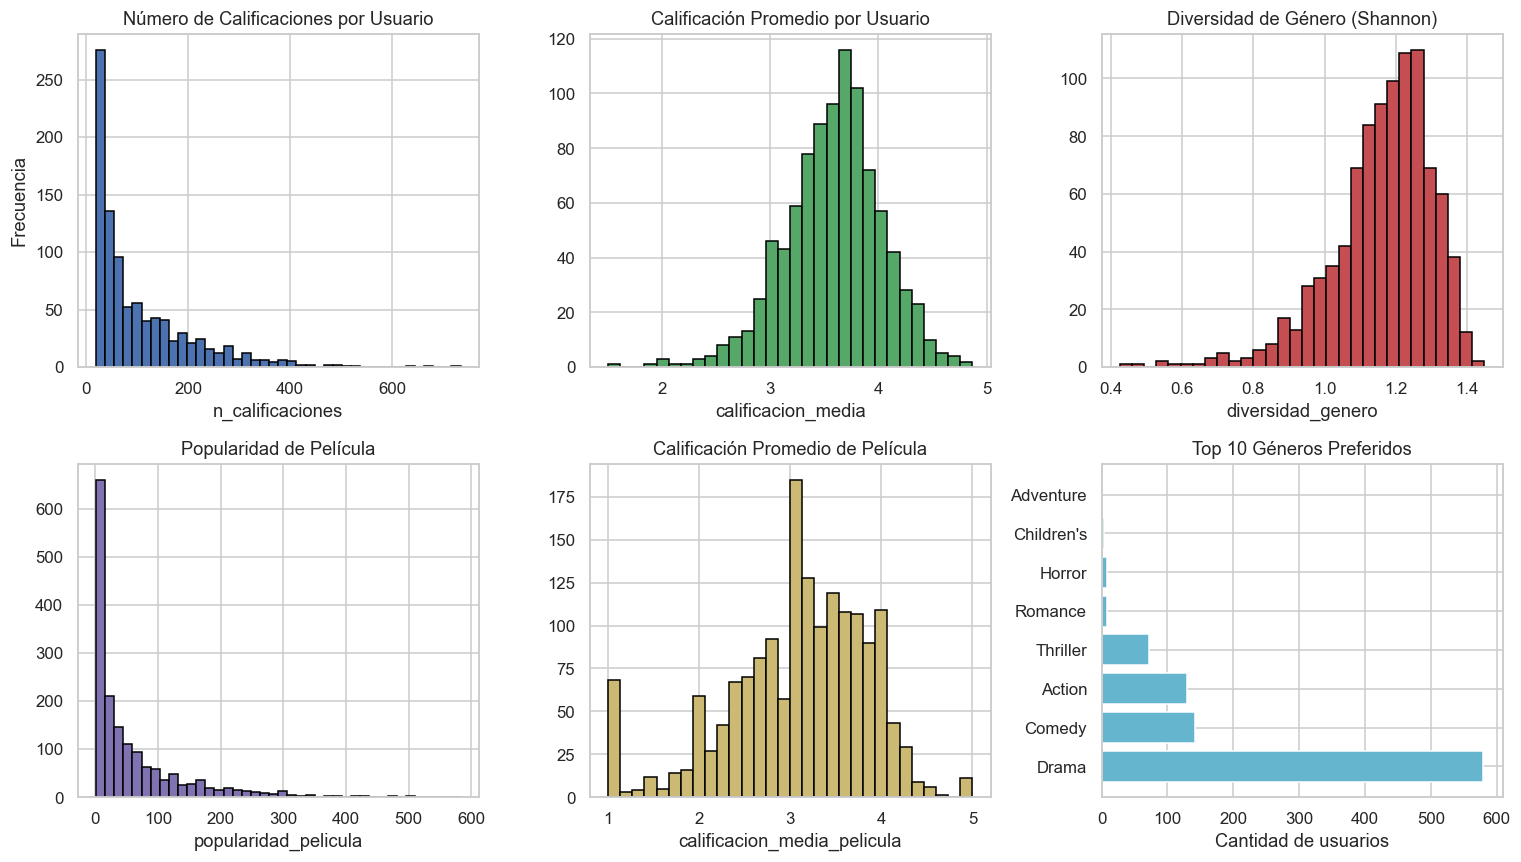

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# n_calificaciones
axes[0, 0].hist(perfil_usuario["n_calificaciones"], bins=40, color="#4C72B0", edgecolor="black")
axes[0, 0].set_title("Número de Calificaciones por Usuario")
axes[0, 0].set_xlabel("n_calificaciones")
axes[0, 0].set_ylabel("Frecuencia")

# calificacion_media
axes[0, 1].hist(perfil_usuario["calificacion_media"], bins=30, color="#55A868", edgecolor="black")
axes[0, 1].set_title("Calificación Promedio por Usuario")
axes[0, 1].set_xlabel("calificacion_media")

# diversidad_genero
axes[0, 2].hist(perfil_usuario["diversidad_genero"], bins=30, color="#C44E52", edgecolor="black")
axes[0, 2].set_title("Diversidad de Género (Shannon)")
axes[0, 2].set_xlabel("diversidad_genero")

# popularidad_pelicula
axes[1, 0].hist(perfil_pelicula["popularidad_pelicula"], bins=40, color="#8172B2", edgecolor="black")
axes[1, 0].set_title("Popularidad de Película")
axes[1, 0].set_xlabel("popularidad_pelicula")

# calificacion_media_pelicula
axes[1, 1].hist(perfil_pelicula["calificacion_media_pelicula"], bins=30, color="#CCB974", edgecolor="black")
axes[1, 1].set_title("Calificación Promedio de Película")
axes[1, 1].set_xlabel("calificacion_media_pelicula")

# genero_preferido
counts = perfil_usuario["genero_preferido"].value_counts().head(10)
axes[1, 2].barh(counts.index, counts.values, color="#64B5CD")
axes[1, 2].set_title("Top 10 Géneros Preferidos")
axes[1, 2].set_xlabel("Cantidad de usuarios")

fig.tight_layout()
plt.show()

## 6. Construcción de la Matriz de Características Final

Para un modelo de recomendación, la matriz de características combina los
atributos del usuario y de la película para cada par (usuario, película).
La variable objetivo es si el usuario calificará positivamente (4-5) esa
película.

In [24]:
# Matriz de características para cada par (usuario, película)
matriz = data_item_user[["user_id", "item_id", "rating"]].copy()
matriz["positiva"] = (matriz["rating"] >= 4).astype(int)

# Agregar atributos del usuario
cols_usuario = ["user_id", "age", "gender", "occupation",
                "n_calificaciones", "calificacion_media", "diversidad_genero"]
matriz = matriz.merge(perfil_usuario[cols_usuario], on="user_id", how="left")

# Agregar atributos de la película
cols_pelicula = ["item_id", "popularidad_pelicula", "calificacion_media_pelicula",
                 "anio_estreno"] + GENEROS
matriz = matriz.merge(perfil_pelicula[cols_pelicula], on="item_id", how="left")

# Agregar perfil de género del usuario (proporción por género)
for genero in GENEROS:
    matriz[f"user_{genero}"] = perfil_usuario.set_index("user_id")[genero].reindex(
        matriz["user_id"]
    ).values

print(f"Matriz final: {matriz.shape[0]} filas, {matriz.shape[1]} columnas")
print(f"\nColumnas: {list(matriz.columns)}")

Matriz final: 99455 filas, 49 columnas

Columnas: ['user_id', 'item_id', 'rating', 'positiva', 'age', 'gender', 'occupation', 'n_calificaciones', 'calificacion_media', 'diversidad_genero', 'popularidad_pelicula', 'calificacion_media_pelicula', 'anio_estreno', 'Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western', 'user_Action', 'user_Adventure', 'user_Animation', "user_Children's", 'user_Comedy', 'user_Crime', 'user_Documentary', 'user_Drama', 'user_Fantasy', 'user_Film-Noir', 'user_Horror', 'user_Musical', 'user_Mystery', 'user_Romance', 'user_Sci-Fi', 'user_Thriller', 'user_War', 'user_Western']


In [25]:
print("Primeras filas de la matriz de características:")
matriz.head()

Primeras filas de la matriz de características:


,user_id,item_id,rating,positiva,age,gender,occupation,n_calificaciones,calificacion_media,diversidad_genero,...,user_Fantasy,user_Film-Noir,user_Horror,user_Musical,user_Mystery,user_Romance,user_Sci-Fi,user_Thriller,user_War,user_Western
0,1,1,5,1,24,M,technician,270,3.603704,1.267029,...,0.007407,0.003704,0.048148,0.048148,0.018519,0.159259,0.159259,0.192593,0.092593,0.022222
1,1,2,3,0,24,M,technician,270,3.603704,1.267029,...,0.007407,0.003704,0.048148,0.048148,0.018519,0.159259,0.159259,0.192593,0.092593,0.022222
2,1,3,4,1,24,M,technician,270,3.603704,1.267029,...,0.007407,0.003704,0.048148,0.048148,0.018519,0.159259,0.159259,0.192593,0.092593,0.022222
3,1,4,3,0,24,M,technician,270,3.603704,1.267029,...,0.007407,0.003704,0.048148,0.048148,0.018519,0.159259,0.159259,0.192593,0.092593,0.022222
4,1,5,3,0,24,M,technician,270,3.603704,1.267029,...,0.007407,0.003704,0.048148,0.048148,0.018519,0.159259,0.159259,0.192593,0.092593,0.022222


## 7. Análisis de Correlación entre Variables Explicativas

Es importante verificar si las variables explicativas están altamente correlacionadas
entre sí (multicolinealidad), ya que esto podría afectar el rendimiento de ciertos
modelos.

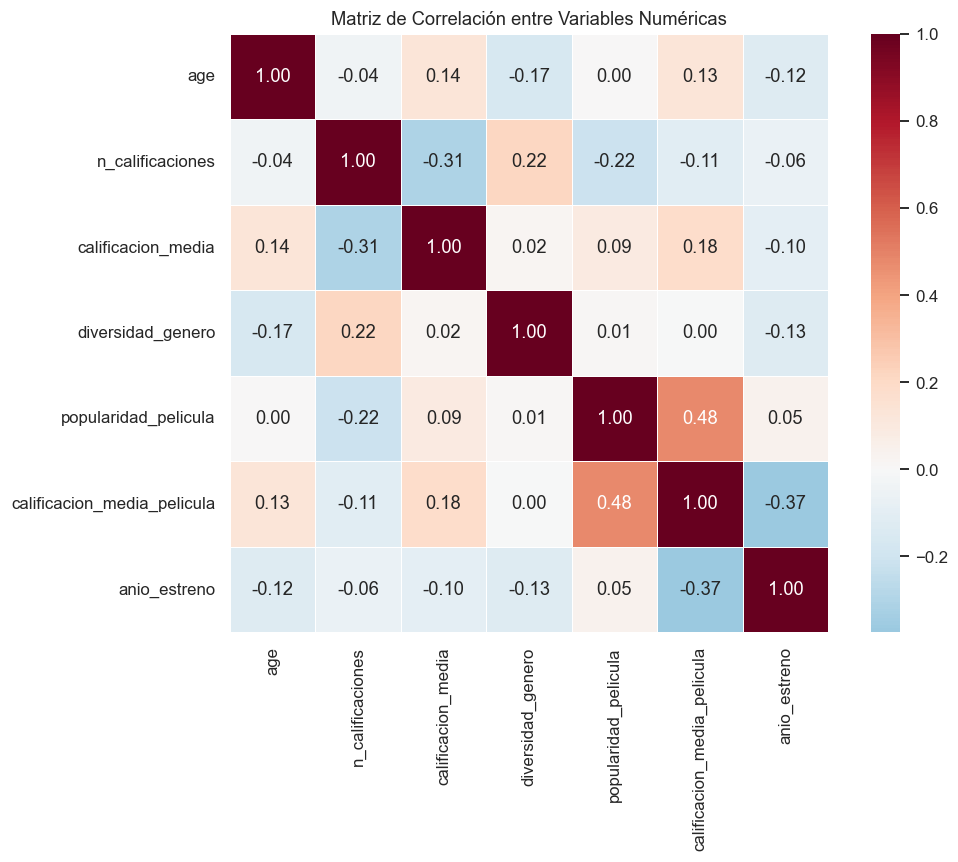

In [26]:
# Seleccionar solo variables numéricas clave para la correlación
vars_numericas = ["age", "n_calificaciones", "calificacion_media", "diversidad_genero",
                  "popularidad_pelicula", "calificacion_media_pelicula", "anio_estreno"]

matriz_muestra = matriz[vars_numericas].dropna()
corr = matriz_muestra.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Matriz de Correlación entre Variables Numéricas")
fig.tight_layout()
plt.show()

**Observaciones:**
- No se esperan correlaciones muy altas entre las variables del usuario y las de la película,
  ya que miden dimensiones distintas.
- La correlación entre `popularidad_pelicula` y `calificacion_media_pelicula` podría ser
  moderada (las películas populares suelen tener calificaciones más estables).
- La diversidad de género no debería correlacionarse fuertemente con la edad, ya que es
  una medida de dispersión, no de tendencia.

## 8. Conclusiones

### Variables Explicativas Definidas

1. **Demográficas (3):** `age`, `gender`, `occupation` — provienen directamente de `user.csv`.

2. **Comportamiento del usuario (5 derivadas):**
   - `n_calificaciones`: volumen de actividad
   - `calificacion_media`: tendencia global
   - `perfil_genero` (19 columnas): distribución de gustos por género
   - `diversidad_genero`: dispersión de gustos (Shannon normalizada)
   - `genero_preferido`: gusto principal

3. **Película (3 originales + 1 derivada):**
   - `Action...Western` (19 binarias): géneros de la película
   - `popularidad_pelicula`: número de calificaciones recibidas
   - `calificacion_media_pelicula`: promedio de calificaciones
   - `anio_estreno`: año de estreno (derivado de `release_date`)

### Variable Objetivo

- **Binaria:** 1 si el usuario calificó la película con 4 o 5 estrellas, 0 en caso contrario.
- **Top 5:** Para cada usuario, las 5 películas con mayor calificación son la "recomendación ideal".

### Justificación General

Las variables elegidas cubren tres dimensiones complementarias:
- **Quién califica** (demografía + comportamiento)
- **Qué se califica** (géneros + popularidad + antigüedad)
- **Cómo se califica** (tendencia + diversidad)

Esta combinación permite construir modelos tanto de filtrado basado en contenido
(content-based) como de filtrado colaborativo (collaborative filtering), o híbridos
que combinen ambos enfoques.